# Assignment 11

## Disclaimer
As we are using dagshub we have a separate file for testing different hyperparameters but this file does the same thing only that it does not include the dagshub connection making it runnable on other computers.

## How to run:
The data folder that is needed is submitted together in the zip file that was handed in, this is beacuse we have already mapped the data to mediapipe. 
All paths should be correct if run correctly, the config is set to the one experiment we used as baseline.
Results of more experiments are placed at the bottom of this file.
To run the notebook just press run all and it includes all data augmentation, the manual file is currently set to A1_kinect.csv but feel free to change the path and check how it does.


## Data mirroring
We begin by doubling the size of the dataset by mirroring both the cut and uncut files around the y-axis.

In [1]:
import pandas as pd
import os
import glob


folders = [
    "datafiles/kinect_good_preprocessed_not_cut_A11_mediapipe",
    "datafiles/kinect_good_preprocessed_A9_mediapipe"
]

pairs = [
    ('left_shoulder', 'right_shoulder'),
    ('left_elbow', 'right_elbow'),
    ('left_wrist', 'right_wrist'),
    ('left_hip', 'right_hip'),
    ('left_knee', 'right_knee'),
    ('left_ankle', 'right_ankle')
]

for target_folder in folders:
    all_files = glob.glob(os.path.join(target_folder, "*.csv"))
    print(f"Processing folder: {target_folder} ({len(all_files)} files found)")
    
    count = 0
    for f in all_files:
        if "_mirrored" in f: 
            continue
        
        df = pd.read_csv(f)
        mirrored_df = df.copy()
        
        x_cols = [c for c in df.columns if "_3d_x" in c]
        mirrored_df[x_cols] = 1.0 - df[x_cols]
        
        for left, right in pairs:
            for axis in ['x', 'y', 'z']:
                l_col = f"{left}_3d_{axis}"
                r_col = f"{right}_3d_{axis}"
                
                if l_col in df.columns and r_col in df.columns:
                    mirrored_df[l_col] = df[r_col]
                    mirrored_df[r_col] = df[l_col]
                    
                    if axis == 'x':
                        mirrored_df[l_col] = 1.0 - mirrored_df[l_col]
                        mirrored_df[r_col] = 1.0 - mirrored_df[r_col]

        new_path = f.replace(".csv", "_mirrored.csv")
        mirrored_df.to_csv(new_path, index=False)
        count += 1

    print(f"Successfully created {count} mirrored files in {target_folder}.\n")

print("All folders processed.")

Processing folder: datafiles/kinect_good_preprocessed_not_cut_A11_mediapipe (360 files found)
Successfully created 180 mirrored files in datafiles/kinect_good_preprocessed_not_cut_A11_mediapipe.

Processing folder: datafiles/kinect_good_preprocessed_A9_mediapipe (358 files found)
Successfully created 179 mirrored files in datafiles/kinect_good_preprocessed_A9_mediapipe.

All folders processed.


## Data labelling - Creating data
Here we join the uncut and cut files to create the actual data. This creates the files we use for training, validation aswell as testing.

In [2]:
import pandas as pd
import os
import glob
from tqdm import tqdm


cut_folder = "datafiles/kinect_good_preprocessed_A9_mediapipe"
uncut_folder = "datafiles/kinect_good_preprocessed_not_cut_A11_mediapipe"
output_folder = "datafiles/labeled_files" 

os.makedirs(output_folder, exist_ok=True)

uncut_files = glob.glob(os.path.join(uncut_folder, "*.csv"))

print(f"Found {len(uncut_files)} uncut files. Starting labeling...")

for uncut_path in tqdm(uncut_files):
    filename = os.path.basename(uncut_path)
    cut_path = os.path.join(cut_folder, filename)
    
    if not os.path.exists(cut_path):
        print(f"Warning: No cut file found for {filename}. Skipping.")
        continue
        
    df_uncut = pd.read_csv(uncut_path)
    df_cut = pd.read_csv(cut_path)
    

    start_frame = df_cut['FrameNo'].min()
    end_frame = df_cut['FrameNo'].max()
    
    # Label 1 if the frame is within the range, otherwise 0
    df_uncut['activity_label'] = (
        (df_uncut['FrameNo'] >= start_frame) & 
        (df_uncut['FrameNo'] <= end_frame)
    ).astype(int)
    
    save_path = os.path.join(output_folder, filename)
    df_uncut.to_csv(save_path, index=False)

print(f"\nDone! Labeled files saved to: {output_folder}")

Found 360 uncut files. Starting labeling...


 34%|███▍      | 122/360 [00:01<00:02, 117.46it/s]

 98%|█████████▊| 354/360 [00:03<00:00, 120.09it/s]

100%|██████████| 360/360 [00:03<00:00, 115.01it/s]


Done! Labeled files saved to: datafiles/labeled_files


## Training the model

## Configuration

In [3]:
experiment_variants = [
    {
        "note": "",
        "seed": 42,
        "seq_length": 5,
        "hidden_size": 128,
        "lr": 0.0005,
        "batch_size": 64,
        "epochs": 30,
        "patience": 5,
        "num_layers": 2,
        "dropout": 0.2,
        "input_size": 39,
        "use_scaling": False,
        "activation": "identity",
        "init": "default",
        "bidirectional": False,
        "rnn_type": "LSTM",
    },
]

### Classes

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torch.nn.init as init
import random
import numpy as np

class ActivityGatekeeper(nn.Module):
    def __init__(self, config):
        super(ActivityGatekeeper, self).__init__()
        
        self.bidirectional = config.get("bidirectional", False)
        multiplier = 2 if self.bidirectional else 1
        
        rnn_type = config.get("rnn_type", "LSTM")
        
        if rnn_type == "GRU":
            self.rnn = nn.GRU(
                config["input_size"], 
                config["hidden_size"], 
                config["num_layers"], 
                batch_first=True, 
                dropout=config["dropout"] if config["num_layers"] > 1 else 0,
                bidirectional=self.bidirectional
            )
        else:
            self.rnn = nn.LSTM(
                config["input_size"], 
                config["hidden_size"], 
                config["num_layers"], 
                batch_first=True, 
                dropout=config["dropout"] if config["num_layers"] > 1 else 0,
                bidirectional=self.bidirectional
            )
        
        if config.get("activation") == "relu":
            self.act = nn.ReLU()
        elif config.get("activation") == "tanh":
            self.act = nn.Tanh()
        else:
            self.act = nn.Identity()
            
        self.fc = nn.Linear(config["hidden_size"] * multiplier, 1)
        
        if config.get("init") == "xavier":
            init.xavier_uniform_(self.fc.weight)
        elif config.get("init") == "kaiming":
            init.kaiming_normal_(self.fc.weight)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_step = out[:, -1, :]
        activated = self.act(last_step)
        return self.fc(activated)

class ActivityDataset(Dataset):
    def __init__(self, file_paths, config, scaler=None):
        self.X, self.y = [], []
        seq_length = config["seq_length"]
        for path in file_paths:
            df = pd.read_csv(path)
            feat_cols = [c for c in df.columns if any(s in c for s in ['_x','_y','_z']) and 'FrameNo' not in c]
            X_data, y_data = df[feat_cols].values.astype('float32'), df['activity_label'].values.astype('float32')
            if scaler is not None:
                X_data = scaler.transform(X_data)

            if len(df) < seq_length: continue
            for i in range(len(df) - seq_length + 1):
                self.X.append(X_data[i : i + seq_length])
                self.y.append(y_data[i + seq_length - 1])
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return torch.tensor(self.X[idx]), torch.tensor([self.y[idx]])

def get_with_mirrors(file_list):
    res = []
    for f in file_list:
        res.append(f)
        m = f.replace(".csv", "_mirrored.csv")
        if os.path.exists(m): res.append(m)
    return res



def set_seed(seed=42):
    random.seed(seed)
    
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Random seed set to: {seed}")




### Resample to make the dataset more balanced

In [5]:
import numpy as np

data_path = "datafiles/labeled_files/"
originals = sorted([f for f in glob.glob(os.path.join(data_path, "*.csv")) if "_mirrored" not in f])

all_labels = []
for f in originals:
    all_labels.extend(pd.read_csv(f)['activity_label'].values)

neg, pos = np.bincount(np.array(all_labels).astype(int))
pos_weight = torch.tensor([neg / pos], dtype=torch.float).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Imbalance ratio: {neg/pos:.2f}")

Imbalance ratio: 0.57


### Training and evaluation

Using device: cpu
Random seed set to: 42

STARTING EXPERIMENT: 

--- Fold 1/10 ---
Fold 1 Results -> Precision: 0.9794, Recall: 0.7886, F1: 0.8737
*** New Experiment Best Found! ***

--- Fold 2/10 ---
Fold 2 Results -> Precision: 0.9505, Recall: 0.8709, F1: 0.9089
*** New Experiment Best Found! ***

--- Fold 3/10 ---
Fold 3 Results -> Precision: 0.9403, Recall: 0.8378, F1: 0.8861

--- Fold 4/10 ---
Fold 4 Results -> Precision: 0.9446, Recall: 0.8434, F1: 0.8912

--- Fold 5/10 ---
Fold 5 Results -> Precision: 0.9710, Recall: 0.7877, F1: 0.8698

--- Fold 6/10 ---
Fold 6 Results -> Precision: 0.9008, Recall: 0.8663, F1: 0.8832

--- Fold 7/10 ---
Fold 7 Results -> Precision: 0.9391, Recall: 0.7900, F1: 0.8581

--- Fold 8/10 ---
Fold 8 Results -> Precision: 0.9463, Recall: 0.8416, F1: 0.8909

--- Fold 9/10 ---
Fold 9 Results -> Precision: 0.9701, Recall: 0.8023, F1: 0.8783

--- Fold 10/10 ---
Fold 10 Results -> Precision: 0.8474, Recall: 0.9724, F1: 0.9056
EXPERIMENT SUMMARY: 
Mean F1: 0.88

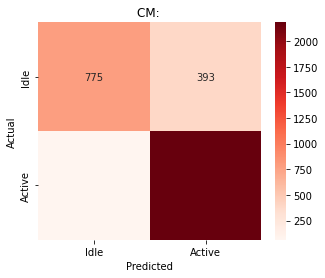


All experiments completed.


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import os
import glob
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Configuration for K-Fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for config in experiment_variants:
    set_seed(config["seed"])
    print(f"\n" + "="*50)
    print(f"STARTING EXPERIMENT: {config.get('note', 'Unnamed')}")
    print("="*50)

    # Metrics for the current experiment across all folds
    cv_fold_scores = []
    cv_p_scores = []
    cv_r_scores = []
    
    best_overall_f1 = 0.0
    best_fold_info = ""

    for fold, (train_idx, test_idx) in enumerate(kf.split(originals)):
        print(f"\n--- Fold {fold+1}/10 ---")

        # Split files
        train_orig = [originals[i] for i in train_idx]
        test_orig = [originals[i] for i in test_idx]

        # Handle Scaling
        scaler = None
        if config.get("use_scaling", False):
            scaler = MinMaxScaler()
            train_samples = []
            for f in train_orig:
                df = pd.read_csv(f)
                feat_cols = [c for c in df.columns if any(s in c for s in ['_x','_y','_z']) and 'FrameNo' not in c]
                train_samples.append(df[feat_cols].values)
            scaler.fit(np.vstack(train_samples))
            print(f"Scaler fitted for Fold {fold+1}")

        # Data Splits
        v_split = int(len(train_orig) * 0.9)
        train_files = get_with_mirrors(train_orig[:v_split])
        val_files = get_with_mirrors(train_orig[v_split:])
        test_files = test_orig 

        # Loaders
        train_loader = DataLoader(ActivityDataset(train_files, config, scaler=scaler), batch_size=config["batch_size"], shuffle=True)
        val_loader = DataLoader(ActivityDataset(val_files, config, scaler=scaler), batch_size=config["batch_size"], shuffle=False)
        test_loader = DataLoader(ActivityDataset(test_files, config, scaler=scaler), batch_size=config["batch_size"], shuffle=False)

        # Model, Optimizer, Criterion
        model = ActivityGatekeeper(config).to(device)
        optimizer = optim.Adam(model.parameters(), lr=config["lr"]) 
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        best_v_loss, patience_count = float('inf'), 0
        fold_checkpoint_path = f"temp_fold_best.pth"

        # Training Loop
        for epoch in range(config["epochs"]):
            model.train()
            for x, y in train_loader:
                optimizer.zero_grad()
                criterion(model(x.to(device)), y.to(device)).backward()
                optimizer.step()

            model.eval()
            v_loss = 0
            with torch.no_grad():
                for x, y in val_loader: 
                    v_loss += criterion(model(x.to(device)), y.to(device)).item()

            avg_v = v_loss / len(val_loader)
            if avg_v < best_v_loss:
                best_v_loss = avg_v
                patience_count = 0
                torch.save(model.state_dict(), fold_checkpoint_path)
            else:
                patience_count += 1
                if patience_count >= config["patience"]: 
                    break

        # Evaluation
        model.load_state_dict(torch.load(fold_checkpoint_path)) 
        model.eval()
        t_true, t_preds = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                outputs = torch.sigmoid(model(inputs))
                t_preds.extend((outputs > 0.5).float().cpu().numpy())
                t_true.extend(labels.numpy())

        p = precision_score(t_true, t_preds, zero_division=0)
        r = recall_score(t_true, t_preds, zero_division=0)
        f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        print(f"Fold {fold+1} Results -> Precision: {p:.4f}, Recall: {r:.4f}, F1: {f1:.4f}")

        cv_fold_scores.append(f1)
        cv_p_scores.append(p)
        cv_r_scores.append(r)

        if f1 > best_overall_f1:
            best_overall_f1 = f1
            torch.save(model.state_dict(), f"best_model.pth")
            if scaler:
                joblib.dump(scaler, f"best_scaler.joblib")
            
            best_fold_info = f"Fold {fold+1} (P: {p:.4f}, R: {r:.4f}, F1: {f1:.4f})"
            print(f"*** New Experiment Best Found! ***")

        # Clean up temporary fold weight
        if os.path.exists(fold_checkpoint_path):
            os.remove(fold_checkpoint_path)

    print(f"EXPERIMENT SUMMARY: {config.get('note', 'Unnamed')}")
    print(f"Mean F1: {np.mean(cv_fold_scores):.4f} (±{np.std(cv_fold_scores):.4f})")
    print(f"Mean Precision: {np.mean(cv_p_scores):.4f}")
    print(f"Mean Recall: {np.mean(cv_r_scores):.4f}")
    print("="*30)

    cm = confusion_matrix(t_true, t_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=['Idle', 'Active'], yticklabels=['Idle', 'Active'])
    plt.title(f"CM: {config.get('note', 'Experiment')}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

print("\nAll experiments completed.")

# One file check for manual control

In [5]:
import torch
import pandas as pd
import numpy as np
import joblib

def extract_exercise_bounds(file_path, model_path, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = ActivityGatekeeper(config).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    scaler = None
    exp_label = config.get("note", "exp").replace(" ", "_")
    scaler_path = f"best_scaler_{exp_label}.joblib"
    
    if config.get("use_scaling", False) and os.path.exists(scaler_path):
        scaler = joblib.load(scaler_path)
        print(f"Using scaler: {scaler_path}")

    df = pd.read_csv(file_path)
    feat_cols = [c for c in df.columns if any(s in c for s in ['_x','_y','_z']) and 'FrameNo' not in c]
    X_raw = df[feat_cols].values.astype('float32')
    frame_numbers = df['FrameNo'].values
    
    X_data = scaler.transform(X_raw) if scaler else X_raw
    
    seq_length = config["seq_length"]
    predictions = []

    with torch.no_grad():
        for i in range(len(df) - seq_length + 1):
            window = X_data[i : i + seq_length]
            window_tensor = torch.tensor(window).unsqueeze(0).to(device)
            output = model(window_tensor)
            prob = torch.sigmoid(output).item()
            predictions.append(1 if prob >= 0.5 else 0)

    full_preds = [0] * (seq_length - 1) + predictions
    
    start_frame = None
    stop_frame = None

    for i in range(1, len(full_preds)):
        if full_preds[i-1] == 0 and full_preds[i] == 1:
            if start_frame is None: start_frame = frame_numbers[i]
        if full_preds[i-1] == 1 and full_preds[i] == 0:
            stop_frame = frame_numbers[i-1]

    return start_frame, stop_frame


best_config = experiment_variants[0] 
model_file = "best_model.pth"
test_csv = "datafiles/kinect_good_preprocessed_not_cut_A11_mediapipe/A1_kinect.csv"

start, stop = extract_exercise_bounds(test_csv,model_file, best_config)


print("Predicted start and end frames for file, ", test_csv)
print("Start frame: ", start)
print("End frame: ", stop)

Predicted start and end frames for file,  datafiles/kinect_good_preprocessed_not_cut_A11_mediapipe/A1_kinect.csv
Start frame:  77
End frame:  184


## Summary of experiments


### Baseline:

**config**

```python
config = 
{
        "note": "",
        "seed": 42,
        "seq_length": 5,
        "hidden_size": 128,
        "lr": 0.0005,
        "batch_size": 64,
        "epochs": 30,
        "patience": 5,
        "num_layers": 2,
        "dropout": 0.2,
        "input_size": 39,
        "use_scaling": False,
        "activation": "identity",
        "init": "default",
        "bidirectional": False,
        "rnn_type": "LSTM",
    },
```
**Optimizer & Scaling**
Used Adam and no scaling

**Results:**

- Mean-Precision: 0.9429031442723433
- Mean-Recall: 0.8195187240987674
- Mean-F1 Score: 0.8760885295559098

### Best result
[Link to prod experiment](https://dagshub.com/SamuelFredricBerg/4dt907/experiments#/experiment/m_d80a1f78b53d481b8db0afab289342e3)


### Experimental Results

Each experiment was evaluated using 10-fold cross-validation on the same splits.
Below is link to dagshub containing all 25 experiments. (A11 - Experiments are all relevant for this)
[Link to all experiments](https://dagshub.com/SamuelFredricBerg/4dt907/experiments)

![Image of experiments](img/MeanF1Comp.png)


### Summary of Experimental Variants

#### Optimization & Initialization
* **Optimizers:** Compared the standard **Adam** against **SGD**.
* **Learning Rates:** Tested different magnitudes, specifically **0.0005** and **0.0001**.
* **Weight Initialization:** Evaluated **Xavier**, **Kaiming** and **Default PyTorch** initialization to manage gradient flow.

#### Neural Network Architecture
* **Hidden Layers (Depth):** Varied the stacking of LSTM layers from **1, 2, 3, to 4 layers**.
* **Hidden Size (Width):** Tested capacities of **64, 128, and 256 units** to balance model power with computational efficiency.
* **Directionality:** Compared standard **Unidirectional** against **Bidirectional** to evaluate if future context helps.

#### Temporal Context & Feature Logic
* **Sequence Length:** Evaluated short windows (**5 frames**) against longer context (**30 frames**).
* **Activation Functions:** Tested the impact of adding **ReLU** or **Tanh** activations to the final fully connected layer versus using raw **Identity** outputs.

#### Data Preprocessing & Regularization
* **Feature Scaling:** Tested **MinMax Scaling (0 to 1)** against **Raw Coordinates**.
* **Dropout Rates:** Varied from **0.2 to 0.5**.
* **Data Augmentation:** Utilized **Mirroring** around the Y-axis to double the dataset size.


## Conclusions

Due to our metrics being not optimal the results almost dont differ at all. As we used F1 as our metric and that we used labelling for all frames there is little to no difference as there are alot of easy frames. We need to remake the model to use another metric that calculates how far off each start and stop is aswell as how the model should handle the possibility of 0, 0, 0, 1, 1, 0, 0, 1, 1, 0 for example.
